<a href="https://colab.research.google.com/github/leonardo2004/Calculo-Numerico/blob/main/Ativade%2002/Atividade02_CalcNumerico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 2
## Leonardo Tomasela Leal - 170291
##Giovanna Maria de Siqueira Junqueira - 185218
##Guilherme Miguel Spyrides Leite Ferro - 176466

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


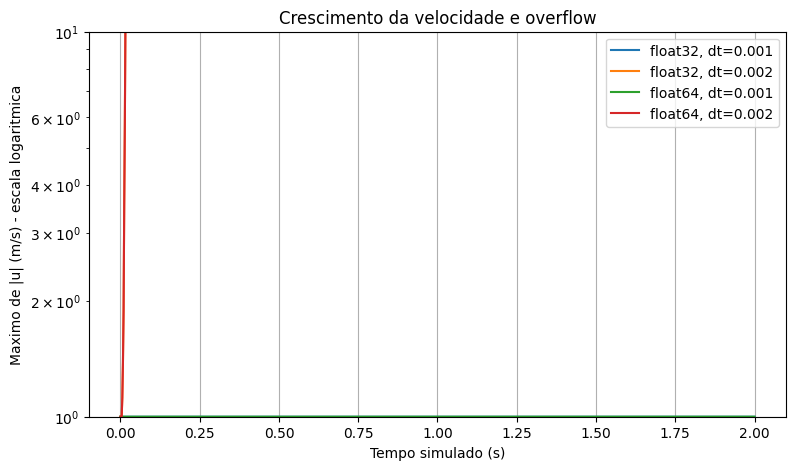

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    global H
    H = 0.01
    global nu
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}



for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

* Caso A: ∆t = 0,001 s, com r = 0,4;
* Caso B: ∆t = 0,002 s, com r = 0,8;

# item 1

In [ ]:
a_delta_t = 0.001
a_r = 0.4
b_delta_t = 0.002
b_r = 0.8
v = 10e-4

dy = H / (2000 - 1)
dt_max = dy**2/(2*v)

print(f"dt máximo: {dt_max} ; dy: {dy} ; r_a: {a_r} ; r_b: {b_r}")
print(f"Estável, {a_delta_t} <= {dt_max} e {a_r} <= {1/2}")

print(f"Instável, {b_delta_t} <= {dt_max} mas {b_r} > {1/2}")

dt máximo: 1.2512509381253909e-08 ; dy: 5.002501250625313e-06 ; r_a : 0.4 ; r_b : 0.8
Estável, 0.001 <= 1.2512509381253909e-08 e 0.4 <= 0.5
Instável, 0.002 <= 1.2512509381253909e-08 mas 0.8 > 0.5


Item 2


Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
----------------------------------------
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


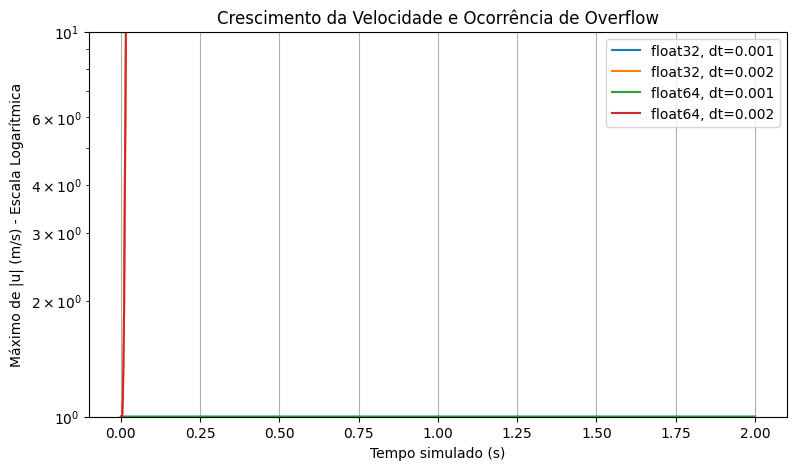

Detecção de Overflow (Tabela de Resultados)

Com base na execução do código acima, os resultados obtidos foram:

| Tipo Numérico | Passo de Tempo ($\Delta t$) | Valor de $r$ | Ocorrência de Overflow | Iteração da Falha |
| :---: | :---: | :---: | :---: | :---: |
| float32 | 0.001 | 0.4 | Não | - |
| float32 | 0.002 | 0.8 | Sim | 156 |
| float64 | 0.001 | 0.4 | Não | - |
| float64 | 0.002 | 0.8 | Sim | 1198 |